In [3]:
import pandas as pd

app = pd.read_csv('../data/raw/application_record.csv')
credit = pd.read_csv('../data/raw/credit_record.csv')

print(app.shape, credit.shape)
print(app.head())
print(credit.head())
print(app.info())
print(app.isnull().sum())

(438557, 18) (1048575, 3)
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Ren

In [9]:
print("Missing values in application_record:")
print(app.isnull().sum()[app.isnull().sum() > 0])

Missing values in application_record:
OCCUPATION_TYPE    134203
dtype: int64


In [11]:
column_notes = pd.DataFrame({
    'column': app.columns,
    'dtype': app.dtypes.values,
    'pct_missing': (app.isnull().mean() * 100).round(2).values
})
column_notes

,column,dtype,pct_missing
0,ID,int64,0.0
1,CODE_GENDER,str,0.0
2,FLAG_OWN_CAR,str,0.0
3,FLAG_OWN_REALTY,str,0.0
4,CNT_CHILDREN,int64,0.0
5,AMT_INCOME_TOTAL,float64,0.0
6,NAME_INCOME_TYPE,str,0.0
7,NAME_EDUCATION_TYPE,str,0.0
8,NAME_FAMILY_STATUS,str,0.0
9,NAME_HOUSING_TYPE,str,0.0


### STATUS label meaning
- 0: 1-29 days past due 
- 1: 30-59 days past due 
- 2: 60-89 days overdue 
- 3: 90-119 days overdue 
- 4: 120-149 days overdue 
- 5: Overdue or bad debts, write-offs for more than 150 days 
- C: paid off that month 
- X: No loan for the month

In [13]:
credit['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [21]:
credit['is_bad'] = credit['STATUS'].isin(['2', '3', '4', '5']).astype(int)

# Aggregate to one row per applicant: bad if EVER bad in their history
target = credit.groupby('ID')['is_bad'].max().reset_index()
target.rename(columns={'is_bad': 'TARGET'}, inplace=True)

target['TARGET'].value_counts(normalize=True)

TARGET
0    0.985495
1    0.014505
Name: proportion, dtype: float64

### Merge: Keep applicants who actually appear in credit_record.csv

In [23]:
df = app.merge(target, on='ID', how='inner')
print("Merged shape:", df.shape)
df.head()

Merged shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


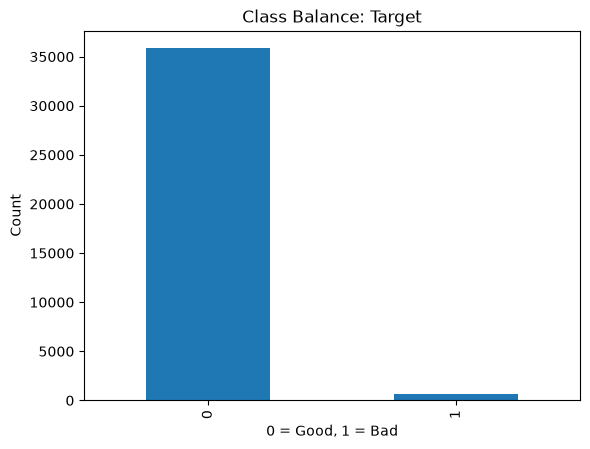

TARGET
0    0.983103
1    0.016897
Name: proportion, dtype: float64


In [27]:
import matplotlib.pyplot as plt

df['TARGET'].value_counts().plot(kind='bar')
plt.title('Class Balance: Target')
plt.xlabel('0 = Good, 1 = Bad')
plt.ylabel('Count')
plt.show()

print(df['TARGET'].value_counts(normalize=True))

### Save merged dataframe

In [32]:
df.to_csv('../data/processed/merged_day1.csv', index=False)